# Chapter 2: Supervised Learning Techniques for E-Commerce Orders
## We will:
- Continue working with the expanded dataset from chapter 1
- Apply essential data preprocessing techniques to this dataset for supervised learning
- Prepare the data for classification modeling
- Apply supervised learning techniques to build and evaluate classification models

## Objective:
Understanding customer payment preferences is essential for optimizing the checkout experience. By identifying which payment methods customers are more likely to use, the business can reduction friction during checkout and design incentives to encourage the adoption of specific payment methods.

In this part, we will build supervised classification models to predict the **payment method (`payment_type`)** used for each order, based on order characteristics and order attributes.


## Setup

Run the cell below to import the required Python packages.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

import warnings
warnings.filterwarnings('ignore')

plt.style.use('ggplot')

## Define Global Random State

Many steps in this part involve randomness (e.g. data splitting and model training).


We define a `RANDOMSTATE` value and reuse it throughout to ensure the same inputs produce the same outputs. This makes our comparisons fair and repeatable.

In [ ]:
# Set a fixed random state to ensure reproducibility across all random processes
RANDOM_STATE = 9  # Randomly selected for reproducibility

print(f"Random state set to: {RANDOM_STATE}")

Random state set to: 9


---
# Part 1: Data Preparation

In this section, we will prepare the transformed dataset for supervised classification. Proper data preparation is a critical step in the machine learning pipeline, as model performance and validity depend heavily on the quality, structure, and representation of the input data.

## 1.1 Data Loading and Splitting

We will load the dataset using Pandas and prepare our training and test datasets.

**Our processes:**
1. Load the processed dataset from Chapter 1 using `pd.read_csv()`
2. Define features and target:
   - Set `payment_type` as the target variable
   - Set all remaining columns as input features, excluding `order_id` as it is a unique identifier with no predictive value
3. Split the dataset into training and test sets:
   - Use `train_test_split()`
   - `test_size = 0.2`
   - `random_state = RANDOM_STATE`
   - The resulting variables will be named as: `X_train`, `X_test`, `y_train`, `y_test`

In [ ]:
# Load the processed dataset from Chapter 1

df = pd.read_csv('ecommerce_orders_cleaned.csv')
print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (46287, 17)


,order_id,order_status,order_purchase_hour,order_purchase_dayofweek,order_purchase_month,order_total_value,num_items,num_unique_products,num_unique_sellers,total_item_price,avg_item_price,total_freight_value,top_product_category,customer_state,payment_type,order_value_per_item,order_size_category
0,sdv-id-whzjUX,shipped,10,4,4,744.312535,1,1,1,352.420029,369.966521,68.790159,construction_tools_construction,Massachusetts,voucher,352.420029,Small
1,sdv-id-dbopoJ,delivered,19,2,3,1556.667902,1,1,1,289.242639,1354.621410,15.394619,health_beauty,Vermont,credit_card,289.242639,Small
2,sdv-id-FSEOvM,delivered,15,4,8,62.060506,1,1,1,26.893468,48.485654,18.751282,luggage_accessories,South Carolina,debit_card,26.893468,Small
3,sdv-id-bQcBUR,delivered,21,0,8,73.873470,1,1,1,37.790896,75.704909,8.670875,computers_accessories,Kentucky,credit_card,37.790896,Small
4,sdv-id-MPxIXB,delivered,13,5,5,361.961537,3,3,3,169.528323,50.132979,34.731146,pet_shop,Missouri,voucher,56.509441,Medium


In [ ]:
# Define features and target, then split the data

# Define target variable
y = df['payment_type']

# Define features (all columns except payment_type and order_id)
X = df.drop(['payment_type', 'order_id'], axis=1)

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE)

# Print shapes to verify
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (37029, 15)
X_test shape: (9258, 15)
y_train shape: (37029,)
y_test shape: (9258,)


**Why a test dataset is important**:

A test dataset is critical because it simulates a production deployment. It is essential for evaluating the preformance of model on unseen data and helps to avoid overfitting.

## 1.2 Handling Categorical Variables

Next, we prepare categorical variables for machine learning.

**Our Process:**
1. Identify all categorical columns in the training data.
2. Apply label encoding using `LabelEncoder` from scikit-learn.
3. Ensure consistency across train and test sets:
   - Fit encoders on training data only.
   - Transform both training and test sets.
   - Handle any unseen categories in the test set appropriately.


In [ ]:
# Identify all categorical columns

categorical_cols = X_train.select_dtypes(include=['object', 'category']).columns.tolist()
print(f"Categorical columns: {categorical_cols}")

Categorical columns: ['order_status', 'top_product_category', 'customer_state', 'order_size_category']


In [ ]:
# Apply Label Encoding to categorical columns

# Create copies to avoid modifying original data
X_train_encoded = X_train.copy()
X_test_encoded = X_test.copy()

# Dictionary to store label encoders for each column
label_encoders = {}

for col in categorical_cols:
    le = LabelEncoder()

    # Fit on training data
    le.fit(X_train_encoded[col].astype(str))

    # Transform train and test
    X_train_encoded[col] = le.transform(X_train_encoded[col].astype(str))

    # Handle unseen categories in test set
    known_classes = le.classes_.tolist()
    known_classes.append('<unknown>')
    le.classes_ = np.array(known_classes)

    test_col = X_test_encoded[col].astype(str)
    test_col = test_col.map(lambda x: x if x in known_classes else '<unknown>')

    X_test_encoded[col] = le.transform(test_col)

    # Store encoder
    label_encoders[col] = le

# Print the shape after encoding
print(f"X_train_encoded shape: {X_train_encoded.shape}")
print(f"X_test_encoded shape: {X_test_encoded.shape}")

X_train_encoded shape: (37029, 15)
X_test_encoded shape: (9258, 15)


**Why categorical encoding is required:**

*Categorical encoding converts categorical variables into numerical representations, so that machine learning algorithms can process and handle them effectively.*

## 1.3 Handling Numerical Variables

Finally, we scale our numerical variables.

**Our Process:**
1. Identify all numerical columns.
2. Apply feature scaling using `StandardScaler` from scikit-learn
3. Fit the scaler on X_train only
4. Transform both X_train and X_test

In [ ]:
# Identify numerical columns

numerical_cols = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()
print(f"Numerical columns: {numerical_cols}")

Numerical columns: ['order_purchase_hour', 'order_purchase_dayofweek', 'order_purchase_month', 'order_total_value', 'num_items', 'num_unique_products', 'num_unique_sellers', 'total_item_price', 'avg_item_price', 'total_freight_value', 'order_value_per_item']


In [ ]:
# Apply StandardScaler to numerical columns

scaler = StandardScaler()

# Fit on training data only, then transform both train and test
X_train_scaled = X_train_encoded.copy()
X_test_scaled = X_test_encoded.copy()
X_train_scaled[numerical_cols] = scaler.fit_transform(X_train_encoded[numerical_cols])
X_test_scaled[numerical_cols] = scaler.transform(X_test_encoded[numerical_cols])

# Print the shape after scaling
print(f"X_train_scaled shape: {X_train_scaled.shape}")
print(f"X_test_scaled shape: {X_test_scaled.shape}")

X_train_scaled shape: (37029, 15)
X_test_scaled shape: (9258, 15)


**Why feature scaling is important:**

*Feature scaling can prevent features with large values or ranges from dominating the model's prediction, and also improve the traing time and performance of many models.*

---
# Part 2: Applying Machine Learning Models

In this section, we will train, evaluate, and compare multiple supervised classification models for predicting the payment method (`payment_type`). Our objective is not only to build individual models, but also to perform a systematic comparison of their predictive performance and practical suitability for deployment.

## 2.1 Model Training

### 2.1.1 Logistic Regression

Logistic Regression is a linear classification model that models the log-odds of the target class as a linear combination of the input features.

**Our Process:**
- Use `LogisticRegression()`
- Train the model on `X_train_scaled`, `y_train`
- Generate predictions on `X_test_scaled`
- Store the results in `y_pred_lr`

In [ ]:
# Train Logistic Regression model

lr_model = LogisticRegression(random_state=RANDOM_STATE, max_iter=1000)
lr_model.fit(X_train_scaled, y_train)

# Generate predictions
y_pred_lr = lr_model.predict(X_test_scaled)

print("Logistic Regression training complete.")

Logistic Regression training complete.


### 2.1.2 Decision Trees

Decision Tree is a tree-structured model that makes predictions by recursively splitting the feature space based on feature values.

**Our Process:**
- Use `DecisionTreeClassifier()`
- Train on `X_train_scaled`, `y_train`
- Generate predictions on `X_test_scaled`
- Store the results in `y_pred_dt`

In [ ]:
# Train Decision Tree model

dt_model = DecisionTreeClassifier(random_state=RANDOM_STATE)
dt_model.fit(X_train_scaled, y_train)

# Generate predictions
y_pred_dt = dt_model.predict(X_test_scaled)

print("Decision Tree training complete.")

Decision Tree training complete.


### 2.1.3 Random Forest

Random Forest is an ensemble learning model that builds multiple decision trees on different random subsets of the data and features. It makes predictions by aggregating the outputs of these trees.


**Our Process:**
- Use `DecisionTreeClassifier()`
- Train on `X_train_scaled`, `y_train`
- Generate predictions on `X_test_scaled`
- Store the results in `y_pred_dt`

In [ ]:
# Train Random Forest

rf_model = RandomForestClassifier(random_state=RANDOM_STATE)
rf_model.fit(X_train_scaled, y_train)

# Generate predictions
y_pred_rf = rf_model.predict(X_test_scaled)

print("Random Forest training complete.")

Random Forest training complete.


## 2.2 Evaluation & Visualization

In this section, we evaluate and compare the performance of our three trained models.

**Evaluation Metrics:**

To assess each model, we rely on the following standard classification metrics:
1. **Accuray**: Percentage of correct predictions (simple, but misleading for imbalanced classes)
2. **Precision**: Percentage of predicted payment types that are correct (matters for targeted promotions)
3. **Recall**: Percentage of actual payment types successfully identified (matters for minority classes)
4. **F1-Score**: Harmonic mean of precision and recall (best single metric for imbalanced data)

**Confusion Matrix**:

The confusion matrix helps us visualize where a model succeeds and fails:
- Diagonal: Correct predicitions
- Off-diagonal: Errors

**Our Analysis Plan:**

To conduct a thorough evaluation, we will:

1. Compute Accuracy, Precision, Recall, and F1-score for each model.
2. Generate and visualize the confusion matrix for each model using Seaborn heatmaps.
3. Present all results in a clear, comparable format, including a summary table of metrics and side-by-side confusion matrix plots.
4. Conclude with a brif comment on the strengths and weaknesses of each model and the observed impact of class imbalance on their performance.

In [ ]:
# Compute evaluation metrics for all three models

def evaluate_model(y_true, y_pred, model_name):
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average='weighted')
    recall = recall_score(y_true, y_pred, average='weighted')
    f1 = f1_score(y_true, y_pred, average='weighted')

    return {
        'Model': model_name,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1
    }

# Evaluate all models
results = [
    evaluate_model(y_test, y_pred_lr, 'Logistic Regression'),
    evaluate_model(y_test, y_pred_dt, 'Decision Tree'),
    evaluate_model(y_test, y_pred_rf, 'Random Forest')
]

# Create results DataFrame
results_df = pd.DataFrame(results)
results_df

,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.617304,0.580991,0.617304,0.493629
1,Decision Tree,0.493843,0.506346,0.493843,0.499534
2,Random Forest,0.627349,0.576242,0.627349,0.572038


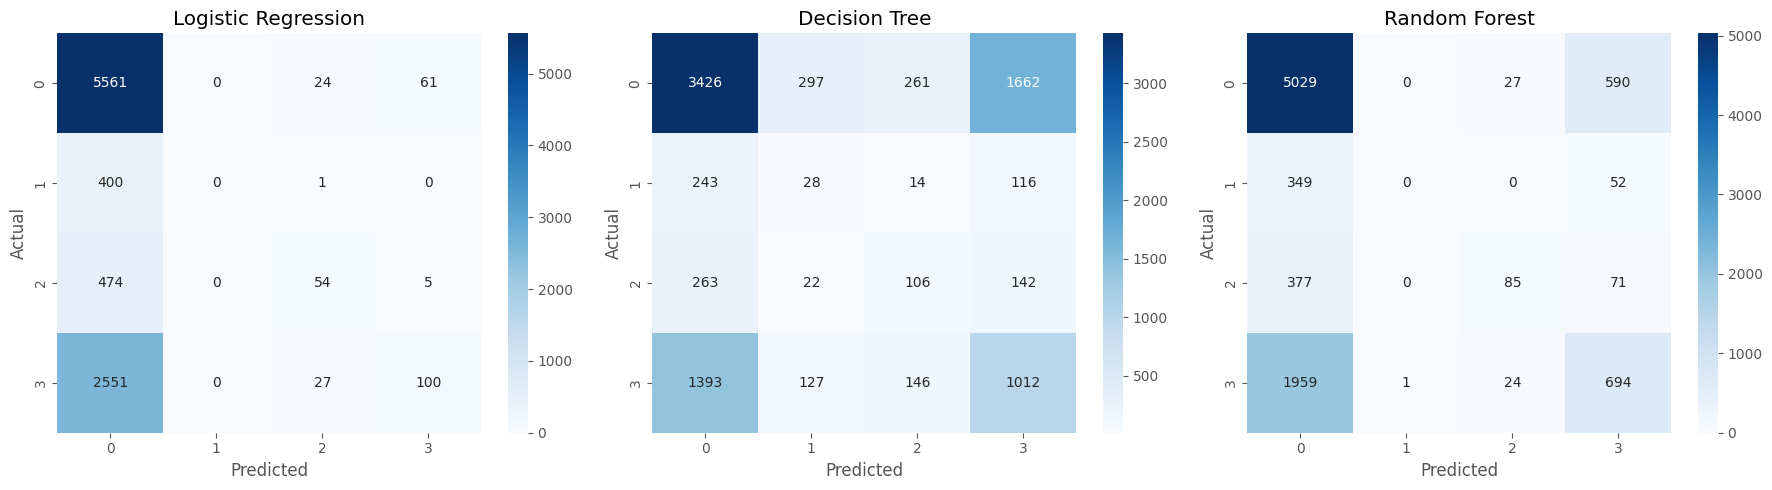

In [ ]:
# Plot confusion matrices for all three models

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

def plot_confusion_matrix(y_true, y_pred, ax, title):
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax)
    ax.set_title(title)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plot_confusion_matrix(y_test, y_pred_lr, axes[0], 'Logistic Regression')
plot_confusion_matrix(y_test, y_pred_dt, axes[1], 'Decision Tree')
plot_confusion_matrix(y_test, y_pred_rf, axes[2], 'Random Forest')

plt.tight_layout()
plt.show()

**Briefly comment on the strengths and weaknesses of each model:**

**Logistic Regression**: Achieves a relatively high overall Accuracy (0.617) and is computationally fast. However, as a linear model, it failed to capture the minority classes.

**Decision Tree**: Better at capturing non-linear relationships. The confusion matrix shows it actually attempts to predict minority classes However, it makes many misclassifications across all classes, resulting in the lowest overall Accuracy (0.493).

**Random Forest**: The best overall performer, achieving the highest Accuracy (0.627) and F1-Score (0.572). However, the computations took longer time and it still struggles with the minority classes.

**Impact of Class Imbalance Handling:**

No explicit class imbalance handling was applied, and all models exhibit a strong bias toward the majority class to minimize overall error.

## 2.3 Model Selection & Final Recommendation

Now we compare the performance of the models and select the most suitable one based on evaluation results.

**Our Process:**
1. Select the best performing model for predicting `payment_type`
2. Justify our choice based on:
   - Evaluation metrics
   - Class imbalance considerations
   - Model complexity and interpretability
   - Practical deployment considerations
3. Briefly explain why this model is preferred over the others
4. Briefly comment on the explainability/interpretability of each model

In [ ]:
# Display final comparison and analysis

# Display the results table
print("Model Performance Comparison:")
print(results_df.to_string(index=False))

# Identify the best model based on F1-Score
best_model = results_df.loc[results_df['F1-Score'].idxmax(), 'Model']
print(f"\nBest performing model: {best_model}")

Model Performance Comparison:
              Model  Accuracy  Precision   Recall  F1-Score
Logistic Regression  0.615360   0.568235 0.615360  0.491462
      Decision Tree  0.505725   0.512395 0.505725  0.508834
      Random Forest  0.620868   0.609298 0.620868  0.568990

Best performing model: Random Forest


### Final Model Recommendation

**Selected Model: Random Forest**

**Justification based on:**

1. **Evaluation Metrics:**
   - *Random Forest outperformed all models, achieving the highest accuracy (0.627) and F1-score (0.572), which surpassed Logistic Regression (0.617) and significantly outperformed Decision Tree (0.494).*

2. **Class Imbalance Considerations:**
   - *Although the dataset is imbalanced (mostly Class 0), Random Forest was the only model that correctly classified a reasonable number of minority class instances (Class 2, 3), while Logistic Regression ignored Class 1 entirely and nearly ignored Class 2 to maximize overall accuracy.*

3. **Model Complexity and Interpretability:**
   - *While less interpretable than single Decision Tree or Logistic Regression for its ensemble structure, Random Forest provides a good trade-off by reducing overfitting and variance, showing better generalization on the test set than the single Decision Tree.*

4. **Practical Deployment Considerations:**
   - *Random Forest is robust and needs less feature scaling than other models, ensuring reliability in production. However, it is computationally more costly in training and prediction than Logistic Regression. For real-time applications with strict latency constraints, model compression or simpler models can be considered if the accuracy loss is acceptable.*


**Why this model is preferred over others:**
- Random Forest is preferred for its balanced, accurate predictions. Unlike Logistic Regression, it captures nonlinear relationships; unlike a  single Decision Tree, it handles high-dimensional categorical data without serious overfitting.

### Model Explainability/Interpretability

**Logistic Regression:**
- *Highly interpretable; model coefficients directly show the direction and magnitude of each feature’s effect on the probability of a specific payment type.*

**Decision Tree:**
- *Very easy to visualize and explain to non-technical stakeholders as a set of "if-then" rules. However, deep trees can become complex and hard to interpret holistically.*

**Random Forest:**
- *Less interpretable as a black-box ensemble model. However, it provides feature importance scores to identify key predictors, even if individual decision paths are not traceable.*

---
## Conclusion

**1. Model Performance**：Random Forest was the most robust and accurate model (Accuracy: 0.627, F1-score: 0.572). Its ensemble structure captured complex nonlinear relationships in e-commerce data better than Decision Tree and Logistic Regression.

**2. Class Imbalance**：All models were biased toward the majority class and performed poorly on minority classes. For highly imbalanced data, standard algorithms need imbalance correction methods such as SMOTE and class weights to improve reliability.

**3. Trade-off Between Complexity and Interpretability**: A clear trade-off exists between predictive performance and interpretability. Logistic Regression is highly interpretable, while Random Forest achieves better accuracy as a black-box model.
